# Hierarchical Clustering

This notebook explores hierarchical clustering, a method that builds a tree of clusters instead of requiring a fixed number of clusters (K).

We will compare it with K-Means and understand how clusters are formed step by step.

## Idea

Hierarchical clustering builds a tree (dendrogram) of data points:

- Start: each point is its own cluster
- Step by step: merge closest clusters
- End: all points become one cluster

You can "cut" the tree at any level to get clusters.

# Prepare data

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

iris_df = pd.read_csv("./data/iris.csv")
mall_df = pd.read_csv("./data/Mall_Customers.csv", index_col="CustomerID")

# Iris (2 features)
features = ["petal_length", "petal_width"]

X_iris = iris_df[features].values
X_iris = StandardScaler().fit_transform(X_iris)

features = ["Annual Income (k$)", "Spending Score (1-100)"]

X_mall = mall_df[features].values
X_mall = StandardScaler().fit_transform(X_mall)

# Run hierarchical clustering

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# fit linkage (core step)
Z = linkage(X_iris, method="ward")

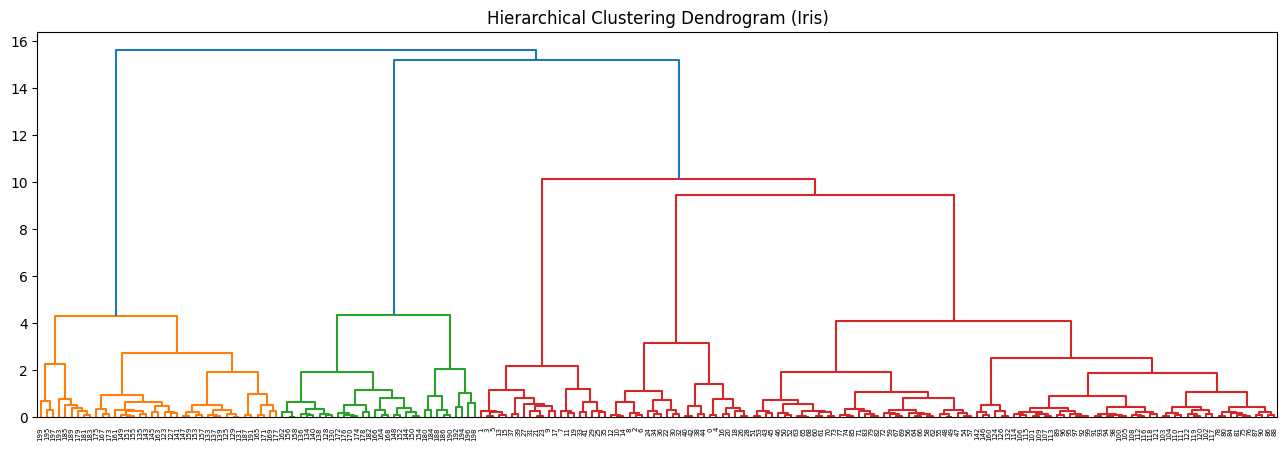

In [8]:
# Plot dendrogram (most important visual)
plt.figure(figsize=(16, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Iris)")
plt.show()

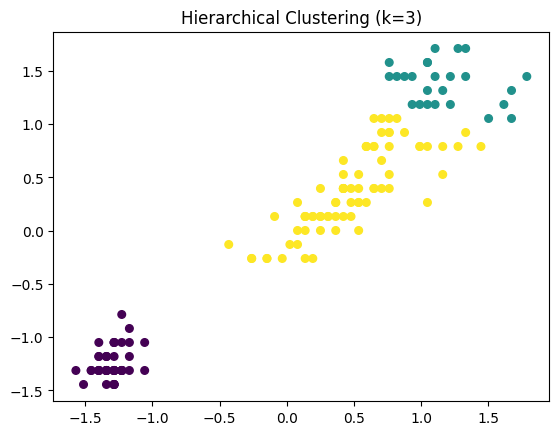

In [5]:
# Choose number of clusters visually
labels = fcluster(Z, t=3, criterion='maxclust')

# 
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=labels, s=30)
plt.title("Hierarchical Clustering (k=3)")
plt.show()

## Key difference vs K-Means

- K-Means:
  - must choose K first
  - flat clustering
  - sensitive to initialization

- Hierarchical:
  - builds full structure first
  - K is chosen after
  - deterministic (no randomness)

# Mall Customers dendrogram (business use case)

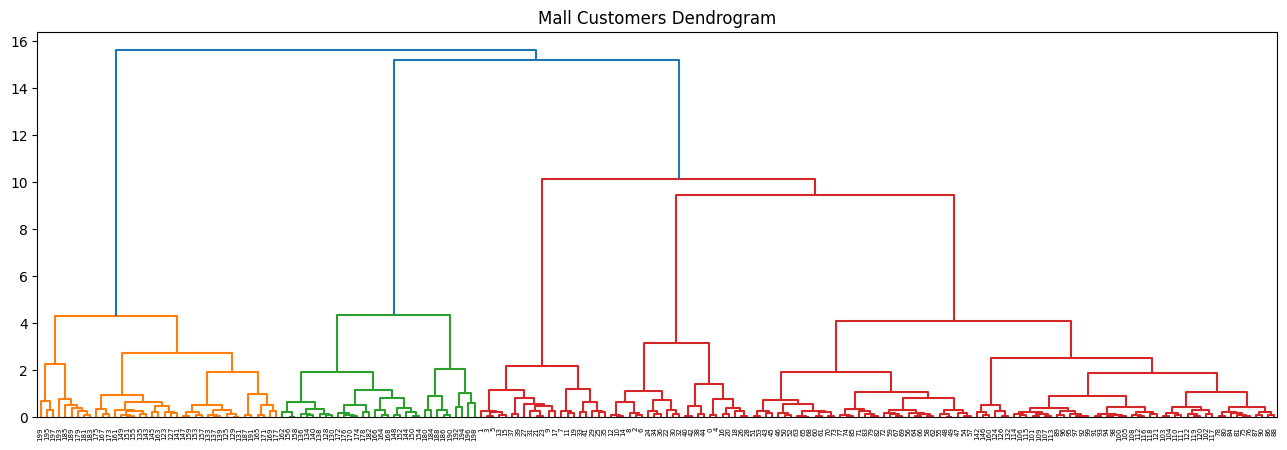

In [7]:
Z = linkage(X_mall, method="ward")

plt.figure(figsize=(16, 5))
dendrogram(Z)
plt.title("Mall Customers Dendrogram")
plt.show()

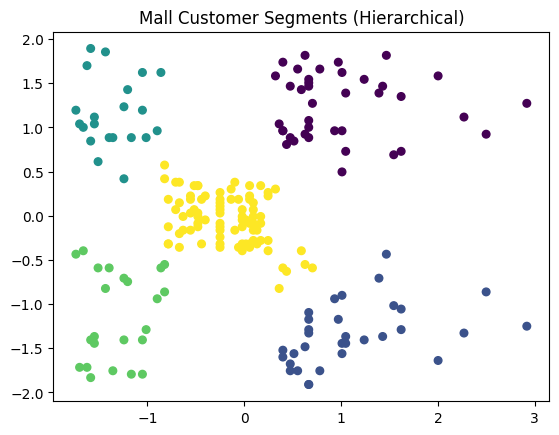

In [9]:
labels = fcluster(Z, t=5, criterion='maxclust')

plt.scatter(X_mall[:, 0], X_mall[:, 1], c=labels, s=30)
plt.title("Mall Customer Segments (Hierarchical)")
plt.show()

Hierarchical clustering builds a full tree of data instead of fixed clusters.

Key advantages:
- No need to choose K upfront
- Deterministic results
- Rich structure (dendrogram)

Key limitation:
- Expensive for large datasets

# Agglomerative Clustering (from scratch)

**Core idea**
1. Start with each point as its own cluster
2. Repeatedly:
    - find the two closest clusters
    - merge them
3. stop when only k clusters remain

We’ll use Euclidean distance between cluster centroids (simplest version).

In [15]:
from mlpeople.models.clustering.hierarchical import agglomerative_clustering
from sklearn.preprocessing import StandardScaler

features = ["petal_length", "petal_width"]
X = iris_df[features].values
X = StandardScaler().fit_transform(X)

labels, clusters = agglomerative_clustering(X, k=3)

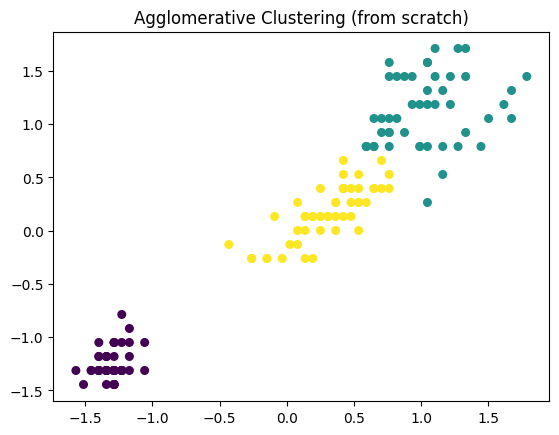

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30)
plt.title("Agglomerative Clustering (from scratch)")
plt.show()

Agglomerative clustering is:
"start from individual points → gradually merge closest groups"

Unlike K-Means:
- no random initialization
- no iterative optimization
- deterministic structure building

## Manual vs SciPy

my current implementation builds hierarchical clustering step-by-step using centroid distance, focusing on learning the mechanics.

SciPy provides an optimized version with multiple linkage methods and dendrogram support.

**Key difference:** my is educational; SciPy is production-ready.

# Linkage methods comparison

Different linkage methods define "cluster similarity" differently.

- Single → nearest points (chain-like clusters)
- Complete → farthest points (compact clusters)
- Average → average distance (balanced behavior)

Same data, same K — but very different cluster structures.


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster

# Prepare data
features = ["Annual Income (k$)", "Spending Score (1-100)"]

X = mall_df[features].values
X = StandardScaler().fit_transform(X)

# Compute linkage matrices
Z_single = linkage(X, method="single")
Z_complete = linkage(X, method="complete")
Z_average = linkage(X, method="average")

# Helper function to plot clustering result
def plot_clusters(X, Z, k, title):
    labels = fcluster(Z, t=k, criterion="maxclust")

    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=30)
    plt.title(title)
    plt.show()

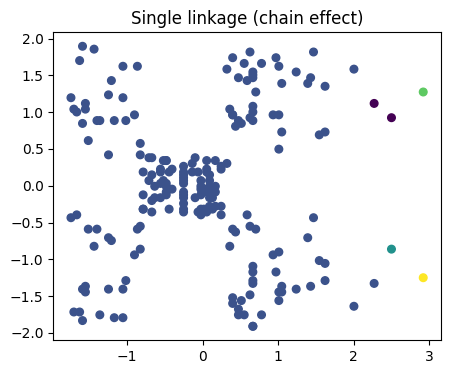

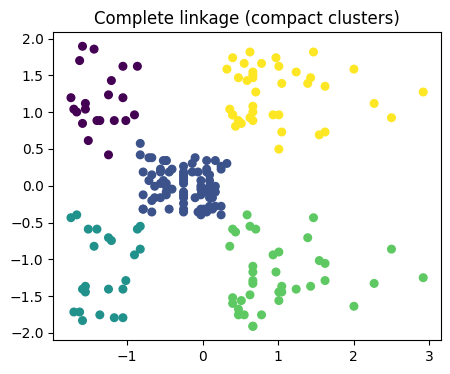

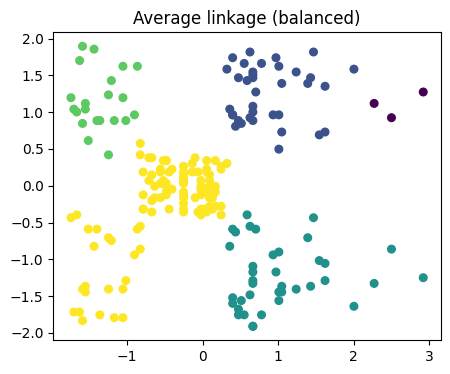

In [59]:
# Compare visually
plot_clusters(X, Z_single, 5, "Single linkage (chain effect)")
plot_clusters(X, Z_complete, 5, "Complete linkage (compact clusters)")
plot_clusters(X, Z_average, 5, "Average linkage (balanced)")

## Linkage methods intuition

The differences between linkage methods come from how we define **distance between clusters**, not from the data itself.

---

### Single linkage (chain effect)

Single linkage defines cluster distance as the **closest pair of points** between two clusters.

**What happens:**
- Clusters merge if *any two points are close*
- Creates long, stretched clusters

**Chain effect:**
A *chain effect* happens when clusters form by step-by-step connections:

A — B — C — D — E

Even if A and E are far apart, they end up in the same cluster through intermediate connections.

**Result:**
- One large “connected” cluster
- A few small separate clusters
- Sensitive to noise and bridges

---

### Complete linkage (compact clusters)

Complete linkage uses the **farthest pair of points** between clusters.

**What happens:**
- Clusters merge only if all points are close
- Encourages compact, tight groups

**Result:**
- Clean, well-separated clusters
- Often similar to K-Means behavior

---

### Average linkage (balanced)

Average linkage uses the **average distance between all points** in two clusters.

**What happens:**
- Balances between single and complete linkage
- Less sensitive to outliers than single linkage
- Less strict than complete linkage

**Result:**
- More stable clustering
- Can merge medium-density groups
- May split or merge clusters depending on overall structure

---

### Summary

| Method    | Distance rule        | Behavior              |
|----------|----------------------|-----------------------|
| Single   | closest points        | chain-like clusters   |
| Complete | farthest points       | compact clusters      |
| Average  | average distance      | balanced clusters     |

---

**Key idea**

All differences come from a single choice:

> how we measure distance between clusters